# Probe Validation Analysis: All Probe Methods and Models

This notebook follows the structure of `notebooks/03_probe_validation_analysis.ipynb`, but expands the analysis to all 12 validation cases:
It is an extension of `notebooks/03.1_multimodel_probe_validation_analysis.ipynb`

- Probe methods: LR, DMM, AttnProbe
- Models: GPT-2, Qwen3-4B, Phi-3-mini-4k-instruct, Llama-3.2-3B

Experiment direction: probes are trained on the implicit AB-randomized dataset and validated on the explicit AB-randomized dataset. The main validation metric is explicit cross-dataset accuracy.

Reproducibility metadata is intentionally skipped here; the focus is analysis and visualization.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.patches import Patch

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

VALIDATION_DIR = ROOT / 'results' / 'probe_validation'
FIGURE_DIR = ROOT / 'results' / 'figures' / 'probe_validation_all_methods'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

METHOD_ORDER = ['lr', 'dmm', 'attn']
METHOD_LABELS = {'lr': 'LR', 'dmm': 'DMM', 'attn': 'AttnProbe'}
MODEL_ORDER = ['gpt2', 'Qwen3-4B', 'Phi-3-mini-4k-instruct', 'Llama-3.2-3B']
MODEL_LABELS = {
    'gpt2': 'GPT-2',
    'Qwen3-4B': 'Qwen3-4B',
    'Phi-3-mini-4k-instruct': 'Phi-3-mini',
    'Llama-3.2-3B': 'Llama-3.2-3B',
}
METHOD_COLORS = {'lr': 'steelblue', 'dmm': 'seagreen', 'attn': 'coral'}
STATUS_COLORS = {'SEMANTIC': 'green', 'WEAK': 'orange', 'LEXICAL': 'red'}

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print(f'Validation directory: {VALIDATION_DIR.relative_to(ROOT)}')
print(f'Figure directory: {FIGURE_DIR.relative_to(ROOT)}')

Validation directory: results/probe_validation
Figure directory: results/figures/probe_validation_all_methods


## Results Overview

Load every method-scoped validation file and create two tables:

- `summary_df`: one row per probe/model case
- `layer_df`: one row per probe/model/layer


In [2]:
def model_short_name(model_name: str) -> str:
    return model_name.split('/')[-1]


def status_from_acc(acc: float) -> str:
    if acc >= 0.70:
        return 'SEMANTIC'
    if acc >= 0.55:
        return 'WEAK'
    return 'LEXICAL'


def load_case(path: Path, method: str) -> tuple[dict, pd.DataFrame]:
    results = json.loads(path.read_text())
    model_name = results['metadata']['model']['name']
    model = model_short_name(model_name)
    summary = results['summary']

    explicit_df = pd.DataFrame(results['explicit_results']).rename(columns={'test_acc': 'explicit_test_acc_alias'})
    implicit_df = pd.DataFrame(results['implicit_results'])
    df = explicit_df.merge(implicit_df, on=['layer', 'probe_method'], how='inner')

    df['method'] = method
    df['method_label'] = METHOD_LABELS[method]
    df['model'] = model
    df['model_label'] = MODEL_LABELS.get(model, model)
    df['model_name'] = model_name
    df['gap'] = df['explicit_acc'] - df['implicit_acc']
    df['status'] = df['explicit_acc'].apply(status_from_acc)
    df['layer_frac'] = df['layer'] / max(int(df['layer'].max()), 1)

    row = {
        'method': method,
        'method_label': METHOD_LABELS[method],
        'model': model,
        'model_label': MODEL_LABELS.get(model, model),
        'model_name': model_name,
        'best_layer': summary['best_semantic_layer'],
        'best_explicit_acc': summary['best_explicit_accuracy'],
        'best_implicit_acc_at_best_explicit': summary['best_implicit_accuracy'],
        'validation_passed': summary['validation_passed'],
        'mean_explicit_acc': summary['mean_explicit_accuracy'],
        'mean_implicit_acc': summary['mean_implicit_accuracy'],
        'mean_gap': summary['mean_generalization_gap'],
        'semantic_layers': summary['semantic_layers'],
        'weak_layers': summary['weak_layers'],
        'lexical_layers': summary['lexical_layers'],
        'n_semantic_layers': len(summary['semantic_layers']),
        'n_layers': int(df['layer'].nunique()),
        'source_json': str(path.relative_to(ROOT)),
    }
    return row, df


summary_rows = []
layer_frames = []
loaded_cases = set()

for method in METHOD_ORDER:
    method_dir = VALIDATION_DIR / method
    for path in sorted(method_dir.glob(f'*_probe_validation_{method}.json')):
        if path.name.startswith('model_comparison'):
            continue
        row, df = load_case(path, method)
        summary_rows.append(row)
        layer_frames.append(df)
        loaded_cases.add((method, row['model']))

summary_df = pd.DataFrame(summary_rows)
layer_df = pd.concat(layer_frames, ignore_index=True)

summary_df['method'] = pd.Categorical(summary_df['method'], METHOD_ORDER, ordered=True)
summary_df['model'] = pd.Categorical(summary_df['model'], MODEL_ORDER, ordered=True)
summary_df = summary_df.sort_values(['method', 'model']).reset_index(drop=True)

layer_df['method'] = pd.Categorical(layer_df['method'], METHOD_ORDER, ordered=True)
layer_df['model'] = pd.Categorical(layer_df['model'], MODEL_ORDER, ordered=True)
layer_df = layer_df.sort_values(['method', 'model', 'layer']).reset_index(drop=True)

expected_cases = {(method, model) for method in METHOD_ORDER for model in MODEL_ORDER}
missing = sorted(expected_cases - loaded_cases)

print(f'Loaded {len(summary_df)} probe/model cases')
print(f'Loaded {len(layer_df)} layer rows')
if missing:
    print('Missing cases:', missing)
else:
    print('All 12 expected cases loaded.')

summary_df[['method_label', 'model_label', 'best_layer', 'best_explicit_acc', 'mean_explicit_acc', 'validation_passed', 'source_json']]

Loaded 12 probe/model cases
Loaded 324 layer rows
All 12 expected cases loaded.


,method_label,model_label,best_layer,best_explicit_acc,mean_explicit_acc,validation_passed,source_json
0,LR,GPT-2,4,0.79,0.737500,True,results/probe_validation/lr/gpt2_probe_validat...
1,LR,Qwen3-4B,18,0.93,0.847500,True,results/probe_validation/lr/Qwen__Qwen3-4B_pro...
2,LR,Phi-3-mini,17,0.94,0.857813,True,results/probe_validation/lr/microsoft__Phi-3-m...
3,LR,Llama-3.2-3B,9,0.92,0.835000,True,results/probe_validation/lr/meta-llama__Llama-...
4,DMM,GPT-2,8,0.74,0.703333,True,results/probe_validation/dmm/gpt2_probe_valida...
5,DMM,Qwen3-4B,16,0.93,0.842500,True,results/probe_validation/dmm/Qwen__Qwen3-4B_pr...
6,DMM,Phi-3-mini,14,0.92,0.840938,True,results/probe_validation/dmm/microsoft__Phi-3-...
7,DMM,Llama-3.2-3B,9,0.91,0.823214,True,results/probe_validation/dmm/meta-llama__Llama...
8,AttnProbe,GPT-2,0,0.60,0.512500,False,results/probe_validation/attn/gpt2_probe_valid...
9,AttnProbe,Qwen3-4B,31,0.72,0.583056,True,results/probe_validation/attn/Qwen__Qwen3-4B_p...


## Visualization: Explicit vs Implicit Accuracy by Layer

This mirrors the original notebook's explicit-vs-implicit bar chart and gap chart, but loops over all 12 probe/model cases.


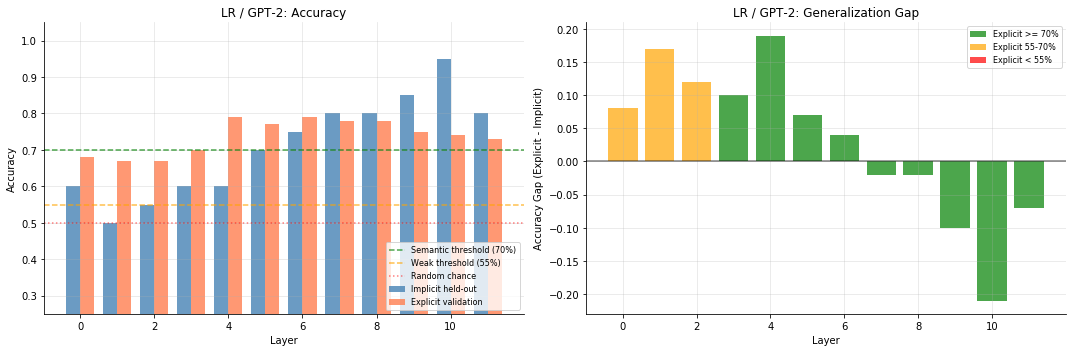

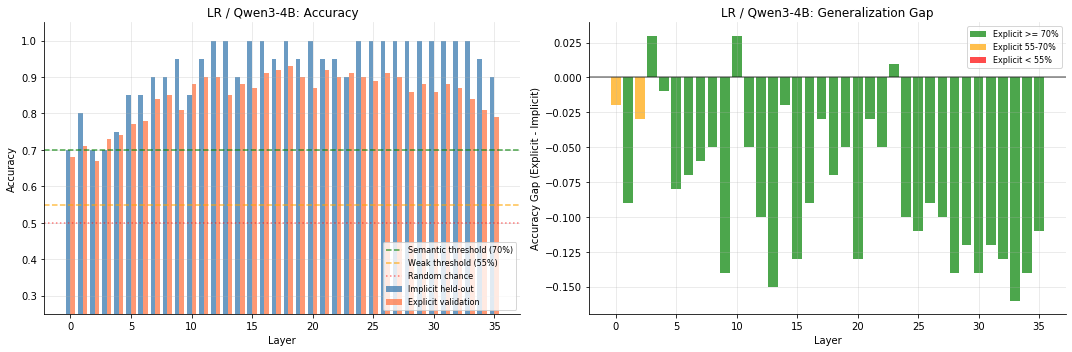

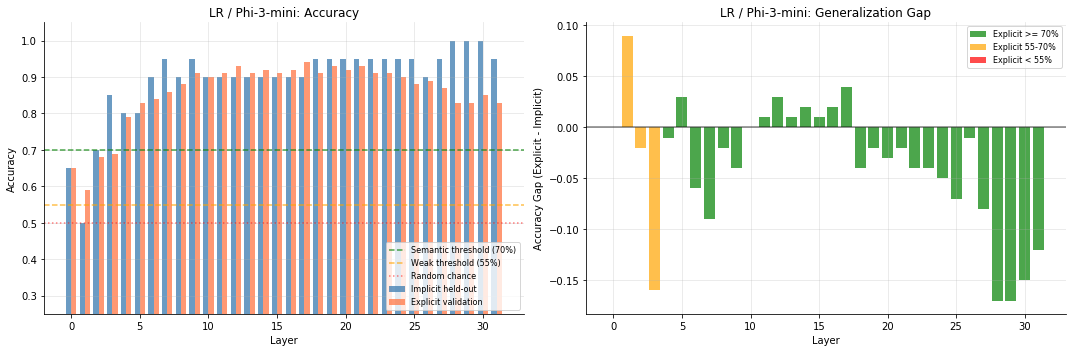

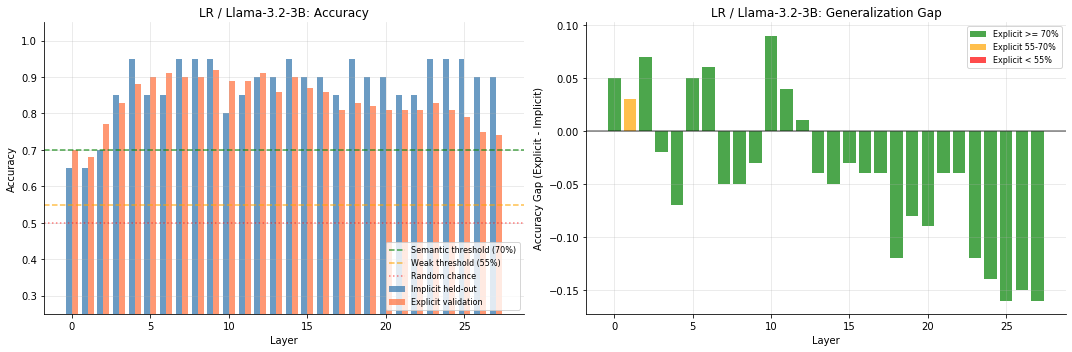

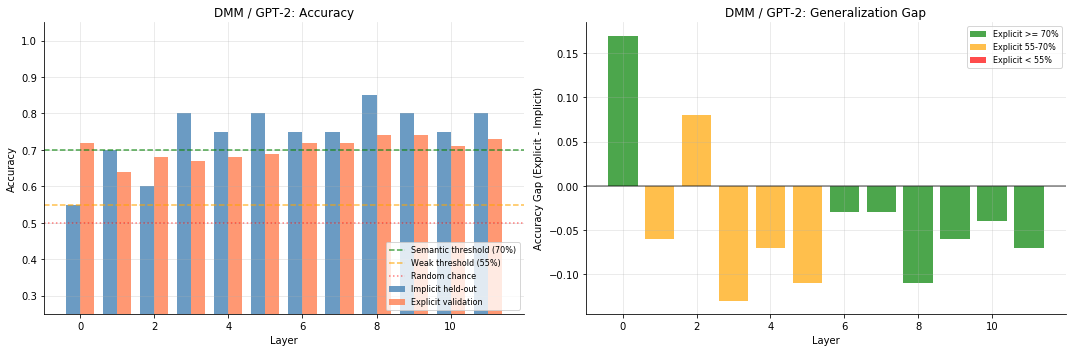

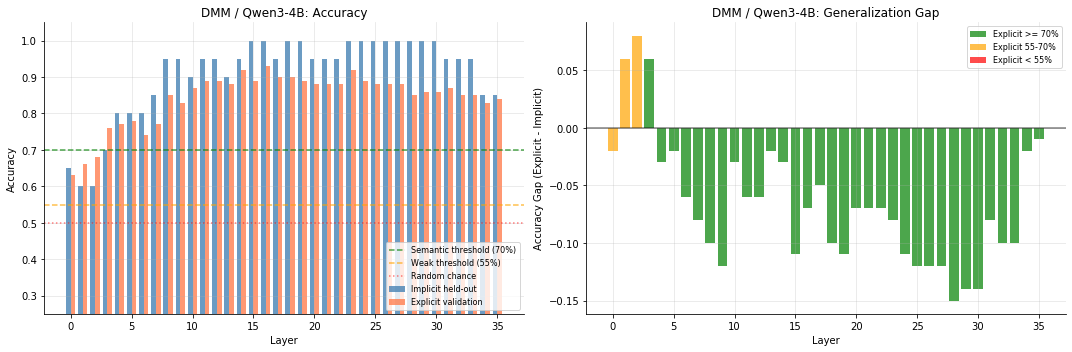

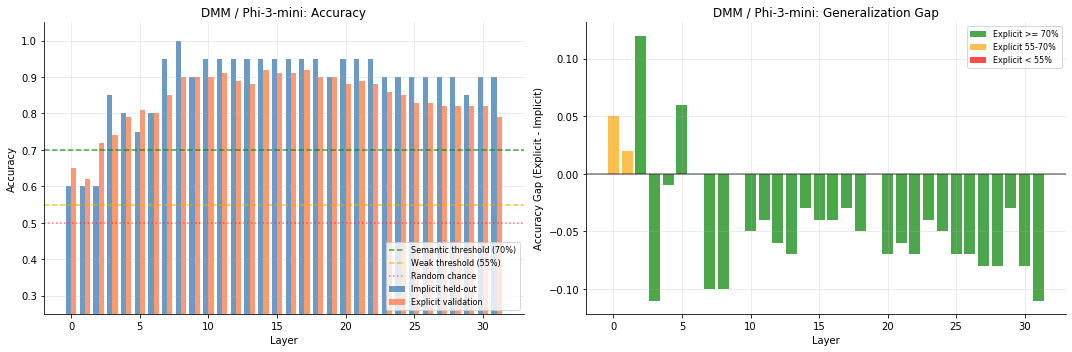

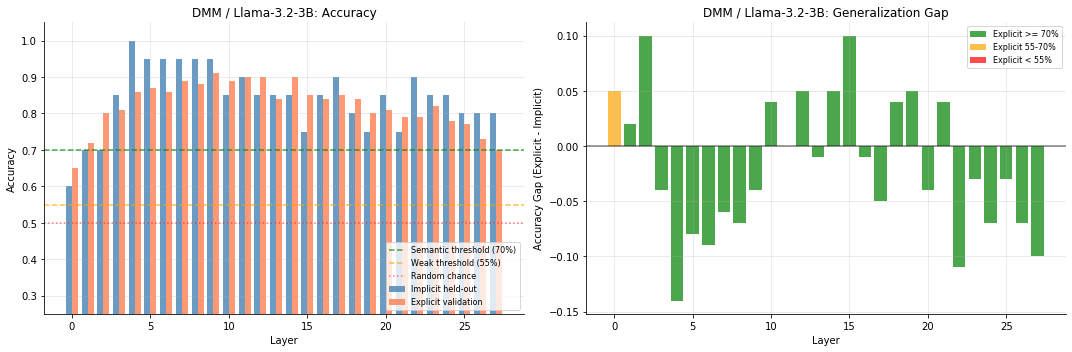

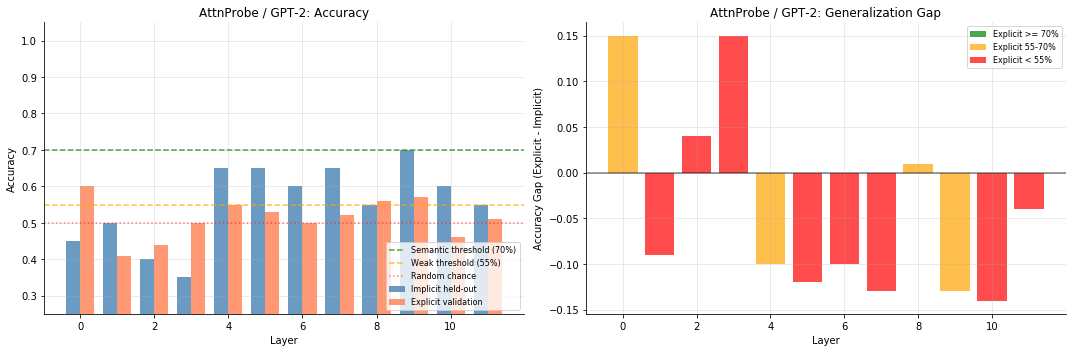

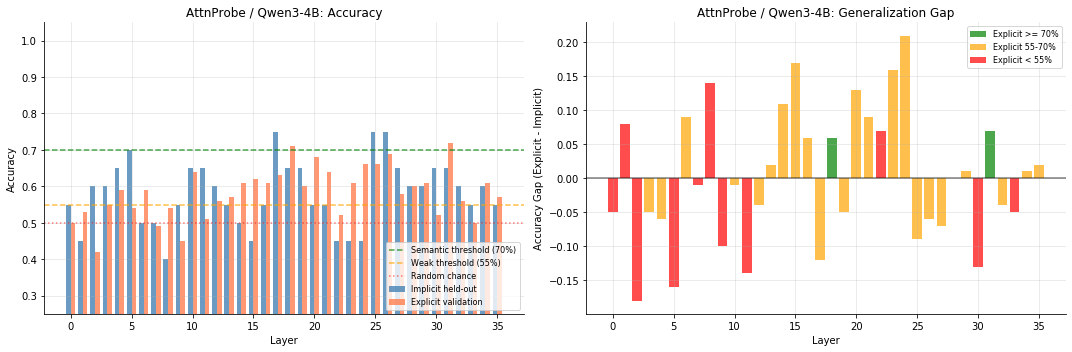

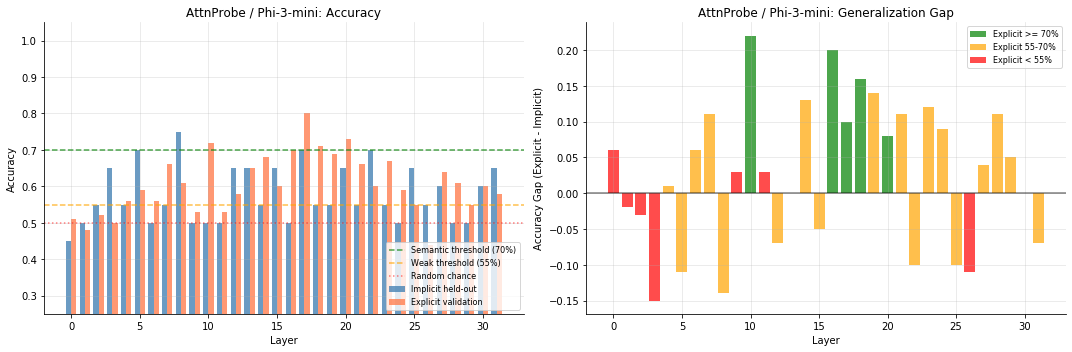

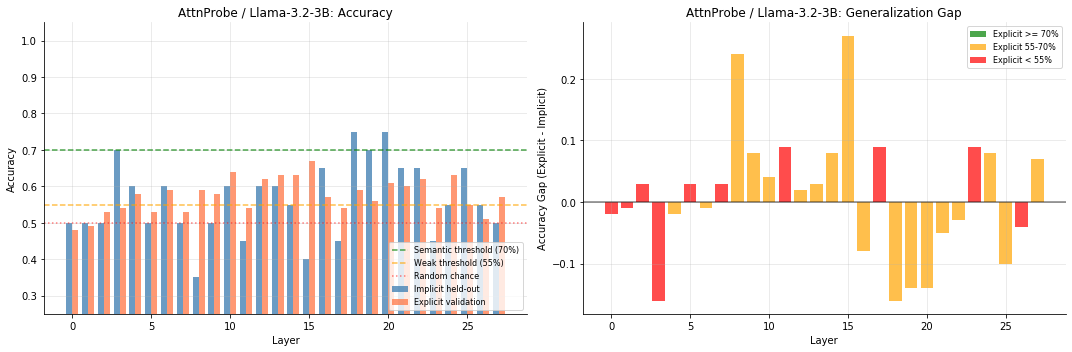

In [3]:
def plot_case_explicit_vs_implicit(method: str, model: str, save: bool = True):
    df = layer_df[(layer_df['method'] == method) & (layer_df['model'] == model)].copy()
    if df.empty:
        raise ValueError(f'No rows for {method=} {model=}')

    label = f"{METHOD_LABELS[method]} / {MODEL_LABELS.get(model, model)}"
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    ax1 = axes[0]
    x = df['layer'].to_numpy()
    width = 0.38
    ax1.bar(x - width/2, df['implicit_acc'], width, label='Implicit held-out', color='steelblue', alpha=0.8)
    ax1.bar(x + width/2, df['explicit_acc'], width, label='Explicit validation', color='coral', alpha=0.8)
    ax1.axhline(y=0.70, color='green', linestyle='--', alpha=0.7, label='Semantic threshold (70%)')
    ax1.axhline(y=0.55, color='orange', linestyle='--', alpha=0.7, label='Weak threshold (55%)')
    ax1.axhline(y=0.50, color='red', linestyle=':', alpha=0.5, label='Random chance')
    ax1.set_xlabel('Layer')
    ax1.set_ylabel('Accuracy')
    ax1.set_title(f'{label}: Accuracy')
    ax1.set_ylim(0.25, 1.05)
    ax1.legend(loc='lower right', fontsize=8)

    ax2 = axes[1]
    colors = [STATUS_COLORS[s] for s in df['status']]
    ax2.bar(x, df['gap'], color=colors, alpha=0.7)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax2.set_xlabel('Layer')
    ax2.set_ylabel('Accuracy Gap (Explicit - Implicit)')
    ax2.set_title(f'{label}: Generalization Gap')
    legend_elements = [
        Patch(facecolor='green', alpha=0.7, label='Explicit >= 70%'),
        Patch(facecolor='orange', alpha=0.7, label='Explicit 55-70%'),
        Patch(facecolor='red', alpha=0.7, label='Explicit < 55%'),
    ]
    ax2.legend(handles=legend_elements, loc='best', fontsize=8)

    fig.tight_layout()
    if save:
        out = FIGURE_DIR / f'explicit_vs_implicit_{method}_{model}.png'
        fig.savefig(out, dpi=150, bbox_inches='tight')
    return fig


for method in METHOD_ORDER:
    for model in MODEL_ORDER:
        plot_case_explicit_vs_implicit(method, model)
        plt.show()

## Compact 12-Case Layer Grid

The individual plots above preserve the original notebook's style. This grid is a quicker all-cases view.


/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ndim = x[:, None].ndim
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


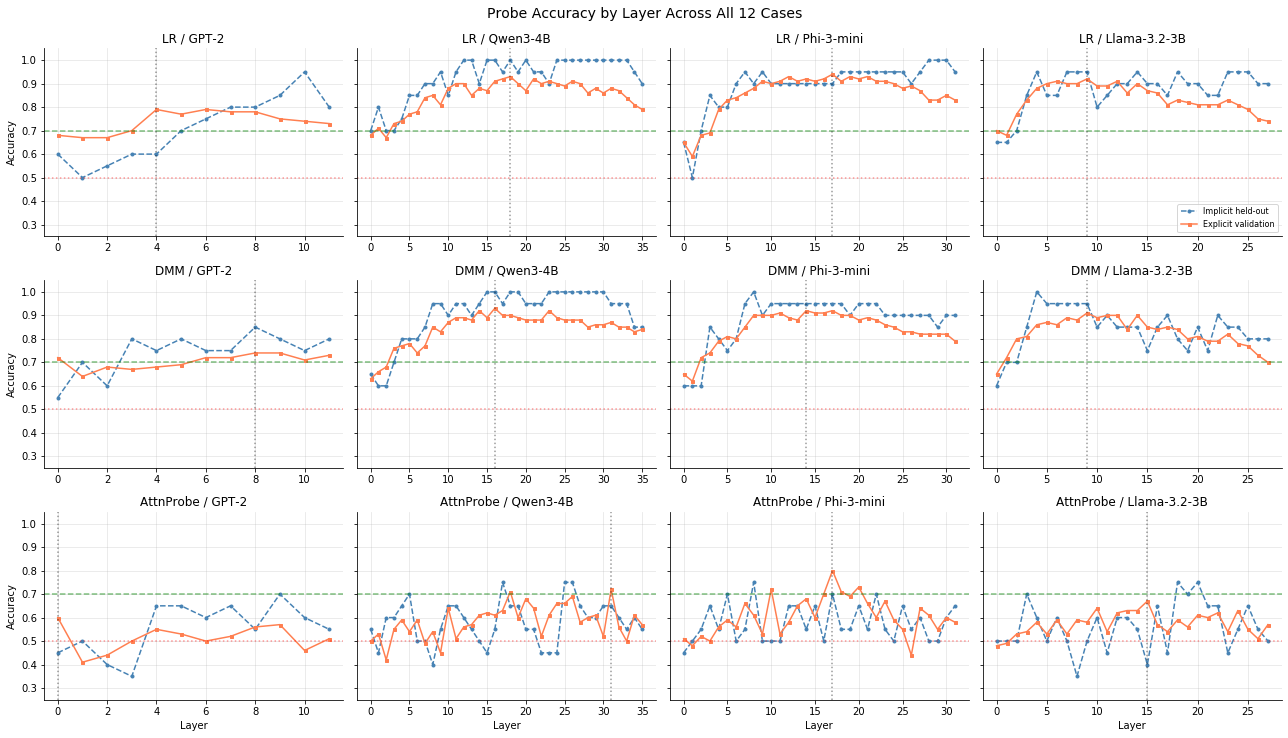

In [4]:
fig, axes = plt.subplots(len(METHOD_ORDER), len(MODEL_ORDER), figsize=(18, 10), sharey=True)
for i, method in enumerate(METHOD_ORDER):
    for j, model in enumerate(MODEL_ORDER):
        ax = axes[i, j]
        df = layer_df[(layer_df['method'] == method) & (layer_df['model'] == model)]
        ax.plot(df['layer'], df['implicit_acc'], 'o--', color='steelblue', label='Implicit held-out', markersize=3)
        ax.plot(df['layer'], df['explicit_acc'], 's-', color='coral', label='Explicit validation', markersize=3)
        ax.axhline(0.70, color='green', linestyle='--', alpha=0.5)
        ax.axhline(0.50, color='red', linestyle=':', alpha=0.4)
        best = summary_df[(summary_df['method'] == method) & (summary_df['model'] == model)].iloc[0]
        ax.axvline(best['best_layer'], color='black', linestyle=':', alpha=0.4)
        ax.set_title(f"{METHOD_LABELS[method]} / {MODEL_LABELS.get(model, model)}")
        ax.set_ylim(0.25, 1.05)
        if i == len(METHOD_ORDER) - 1:
            ax.set_xlabel('Layer')
        if j == 0:
            ax.set_ylabel('Accuracy')
        if i == 0 and j == len(MODEL_ORDER) - 1:
            ax.legend(fontsize=8)
fig.suptitle('Probe Accuracy by Layer Across All 12 Cases', y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'all_cases_layer_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## Layer-by-Layer Analysis

This is the text version of the original notebook's layer-by-layer report, repeated for every probe/model pair.


In [5]:
for method in METHOD_ORDER:
    for model in MODEL_ORDER:
        df = layer_df[(layer_df['method'] == method) & (layer_df['model'] == model)]
        print('=' * 80)
        print(f"LAYER-BY-LAYER ANALYSIS: {METHOD_LABELS[method]} / {MODEL_LABELS.get(model, model)}")
        print('=' * 80)
        for _, row in df.iterrows():
            layer = int(row['layer'])
            implicit = row['implicit_acc']
            explicit = row['explicit_acc']
            gap = row['gap']
            status = row['status']
            marker = 'PASS' if status == 'SEMANTIC' else ('WEAK' if status == 'WEAK' else 'FAIL')
            print(
                f"Layer {layer:2d}: {marker:4s} {status:8s} | "
                f"Implicit: {implicit:.1%} | Explicit: {explicit:.1%} | Gap: {gap:+.1%}"
            )
        print()

LAYER-BY-LAYER ANALYSIS: LR / GPT-2
Layer  0: WEAK WEAK     | Implicit: 60.0% | Explicit: 68.0% | Gap: +8.0%
Layer  1: WEAK WEAK     | Implicit: 50.0% | Explicit: 67.0% | Gap: +17.0%
Layer  2: WEAK WEAK     | Implicit: 55.0% | Explicit: 67.0% | Gap: +12.0%
Layer  3: PASS SEMANTIC | Implicit: 60.0% | Explicit: 70.0% | Gap: +10.0%
Layer  4: PASS SEMANTIC | Implicit: 60.0% | Explicit: 79.0% | Gap: +19.0%
Layer  5: PASS SEMANTIC | Implicit: 70.0% | Explicit: 77.0% | Gap: +7.0%
Layer  6: PASS SEMANTIC | Implicit: 75.0% | Explicit: 79.0% | Gap: +4.0%
Layer  7: PASS SEMANTIC | Implicit: 80.0% | Explicit: 78.0% | Gap: -2.0%
Layer  8: PASS SEMANTIC | Implicit: 80.0% | Explicit: 78.0% | Gap: -2.0%
Layer  9: PASS SEMANTIC | Implicit: 85.0% | Explicit: 75.0% | Gap: -10.0%
Layer 10: PASS SEMANTIC | Implicit: 95.0% | Explicit: 74.0% | Gap: -21.0%
Layer 11: PASS SEMANTIC | Implicit: 80.0% | Explicit: 73.0% | Gap: -7.0%

LAYER-BY-LAYER ANALYSIS: LR / Qwen3-4B
Layer  0: WEAK WEAK     | Implicit: 70.0% 

## Summary Statistics

The table below is the main comparison table. `Best explicit accuracy` is the cross-dataset validation criterion.


In [6]:
summary_display = summary_df[[
    'method_label', 'model_label', 'best_layer', 'best_explicit_acc',
    'best_implicit_acc_at_best_explicit', 'mean_explicit_acc', 'mean_implicit_acc',
    'mean_gap', 'n_semantic_layers', 'n_layers', 'validation_passed'
]].rename(columns={
    'method_label': 'Probe',
    'model_label': 'Model',
    'best_layer': 'Best semantic layer',
    'best_explicit_acc': 'Best explicit accuracy',
    'best_implicit_acc_at_best_explicit': 'Implicit accuracy at best explicit layer',
    'mean_explicit_acc': 'Mean explicit accuracy',
    'mean_implicit_acc': 'Mean implicit accuracy',
    'mean_gap': 'Mean gap',
    'n_semantic_layers': '# semantic layers',
    'n_layers': '# total layers',
    'validation_passed': 'Validation passed',
})

summary_display.style.format({
    'Best explicit accuracy': '{:.1%}',
    'Implicit accuracy at best explicit layer': '{:.1%}',
    'Mean explicit accuracy': '{:.1%}',
    'Mean implicit accuracy': '{:.1%}',
    'Mean gap': '{:+.1%}',
})

,Probe,Model,Best semantic layer,Best explicit accuracy,Implicit accuracy at best explicit layer,Mean explicit accuracy,Mean implicit accuracy,Mean gap,# semantic layers,# total layers,Validation passed
0,LR,GPT-2,4,79.0%,60.0%,73.8%,70.8%,+2.9%,9,12,1
1,LR,Qwen3-4B,18,93.0%,100.0%,84.8%,92.6%,-7.9%,34,36,1
2,LR,Phi-3-mini,17,94.0%,90.0%,85.8%,89.4%,-3.6%,28,32,1
3,LR,Llama-3.2-3B,9,92.0%,95.0%,83.5%,87.5%,-4.0%,27,28,1
4,DMM,GPT-2,8,74.0%,85.0%,70.3%,74.2%,-3.8%,7,12,1
5,DMM,Qwen3-4B,16,93.0%,100.0%,84.2%,90.8%,-6.6%,33,36,1
6,DMM,Phi-3-mini,14,92.0%,95.0%,84.1%,88.1%,-4.0%,30,32,1
7,DMM,Llama-3.2-3B,9,91.0%,95.0%,82.3%,84.1%,-1.8%,27,28,1
8,AttnProbe,GPT-2,0,60.0%,45.0%,51.2%,55.4%,-4.2%,0,12,0
9,AttnProbe,Qwen3-4B,31,72.0%,65.0%,58.3%,58.1%,+0.2%,2,36,1


In [7]:
for row in summary_df.itertuples(index=False):
    print('=' * 70)
    print(f"VALIDATION SUMMARY: {row.method_label} / {row.model_label}")
    print('=' * 70)
    print(f"Best semantic layer: {row.best_layer}")
    print(f"Best explicit accuracy: {row.best_explicit_acc:.1%}")
    print(f"Implicit accuracy at best explicit layer: {row.best_implicit_acc_at_best_explicit:.1%}")
    print(f"Validation passed: {row.validation_passed}")
    print(f"Semantic layers (>70% explicit): {row.semantic_layers}")
    print(f"Weak layers (55-70% explicit): {row.weak_layers}")
    print(f"Lexical layers (<55% explicit): {row.lexical_layers}")
    print(f"Mean explicit accuracy: {row.mean_explicit_acc:.1%}")
    print(f"Mean implicit accuracy: {row.mean_implicit_acc:.1%}")
    print(f"Mean generalization gap: {row.mean_gap:+.1%}")
    print()

VALIDATION SUMMARY: LR / GPT-2
Best semantic layer: 4
Best explicit accuracy: 79.0%
Implicit accuracy at best explicit layer: 60.0%
Validation passed: True
Semantic layers (>70% explicit): [3, 4, 5, 6, 7, 8, 9, 10, 11]
Weak layers (55-70% explicit): [0, 1, 2]
Lexical layers (<55% explicit): []
Mean explicit accuracy: 73.8%
Mean implicit accuracy: 70.8%
Mean generalization gap: +2.9%

VALIDATION SUMMARY: LR / Qwen3-4B
Best semantic layer: 18
Best explicit accuracy: 93.0%
Implicit accuracy at best explicit layer: 100.0%
Validation passed: True
Semantic layers (>70% explicit): [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
Weak layers (55-70% explicit): [0, 2]
Lexical layers (<55% explicit): []
Mean explicit accuracy: 84.8%
Mean implicit accuracy: 92.6%
Mean generalization gap: -7.9%

VALIDATION SUMMARY: LR / Phi-3-mini
Best semantic layer: 17
Best explicit accuracy: 94.0%
Implicit accuracy at best explicit 

## Interpretation

The following findings are generated directly from the loaded results.


In [8]:
best_overall = summary_df.loc[summary_df['best_explicit_acc'].idxmax()]
method_means = summary_df.groupby('method', observed=True)['mean_explicit_acc'].mean().sort_values(ascending=False)
failed = summary_df[~summary_df['validation_passed']]

lines = []
lines.append(
    f"- Best single case: {best_overall['method_label']} / {best_overall['model_label']} "
    f"at layer {int(best_overall['best_layer'])}, explicit accuracy {best_overall['best_explicit_acc']:.1%}."
)
lines.append(
    f"- Best average method: {METHOD_LABELS[method_means.index[0]]}, "
    f"mean explicit accuracy {method_means.iloc[0]:.1%} across models."
)

for model in MODEL_ORDER:
    sub = summary_df[summary_df['model'] == model]
    row = sub.loc[sub['best_explicit_acc'].idxmax()]
    lines.append(
        f"- Best probe for {MODEL_LABELS.get(model, model)}: {row['method_label']} "
        f"at layer {int(row['best_layer'])}, explicit accuracy {row['best_explicit_acc']:.1%}."
    )

if failed.empty:
    lines.append('- All cases pass the 70% explicit validation threshold.')
else:
    failed_text = ', '.join(
        f"{row.method_label}/{row.model_label} ({row.best_explicit_acc:.1%})"
        for row in failed.itertuples(index=False)
    )
    lines.append(f"- Cases below the 70% explicit validation threshold: {failed_text}.")

display(Markdown('\n'.join(lines)))

- Best single case: LR / Phi-3-mini at layer 17, explicit accuracy 94.0%.
- Best average method: LR, mean explicit accuracy 81.9% across models.
- Best probe for GPT-2: LR at layer 4, explicit accuracy 79.0%.
- Best probe for Qwen3-4B: LR at layer 18, explicit accuracy 93.0%.
- Best probe for Phi-3-mini: LR at layer 17, explicit accuracy 94.0%.
- Best probe for Llama-3.2-3B: LR at layer 9, explicit accuracy 92.0%.
- Cases below the 70% explicit validation threshold: AttnProbe/GPT-2 (60.0%), AttnProbe/Llama-3.2-3B (67.0%).

## Heatmap Visualization

This generalizes the original implicit-accuracy heatmap to all models and probe methods.


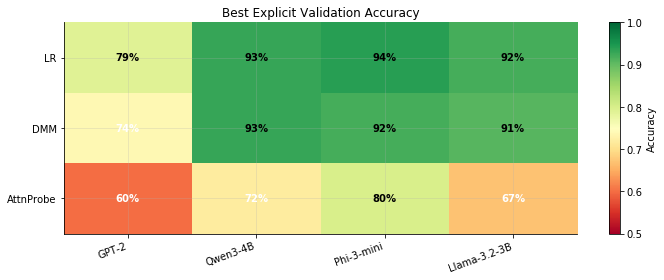

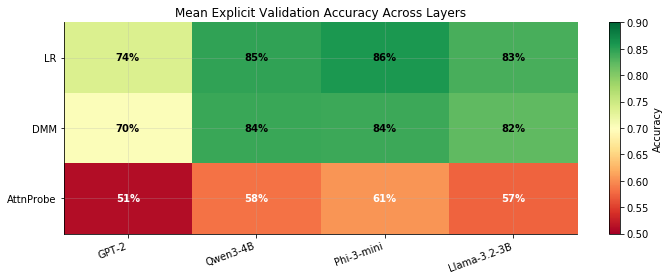

In [9]:
def annotated_heatmap(pivot, title, filename, vmin=0.5, vmax=1.0, fmt='{:.0%}', cmap='RdYlGn'):
    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(pivot.values, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=20, ha='right')
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(title)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            value = pivot.values[i, j]
            color = 'white' if value < (vmin + vmax) / 2 else 'black'
            ax.text(j, i, fmt.format(value), ha='center', va='center', color=color, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Accuracy')
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()

best_pivot = summary_df.pivot(index='method_label', columns='model_label', values='best_explicit_acc')
best_pivot = best_pivot.loc[[METHOD_LABELS[m] for m in METHOD_ORDER], [MODEL_LABELS[m] for m in MODEL_ORDER]]
annotated_heatmap(best_pivot, 'Best Explicit Validation Accuracy', 'best_explicit_accuracy_heatmap.png')

mean_pivot = summary_df.pivot(index='method_label', columns='model_label', values='mean_explicit_acc')
mean_pivot = mean_pivot.loc[[METHOD_LABELS[m] for m in METHOD_ORDER], [MODEL_LABELS[m] for m in MODEL_ORDER]]
annotated_heatmap(mean_pivot, 'Mean Explicit Validation Accuracy Across Layers', 'mean_explicit_accuracy_heatmap.png', vmin=0.5, vmax=0.9)

## Normalized Layer Heatmaps

Each model has a different number of layers. The next plot bins layers into normalized depth buckets so model families are easier to compare.


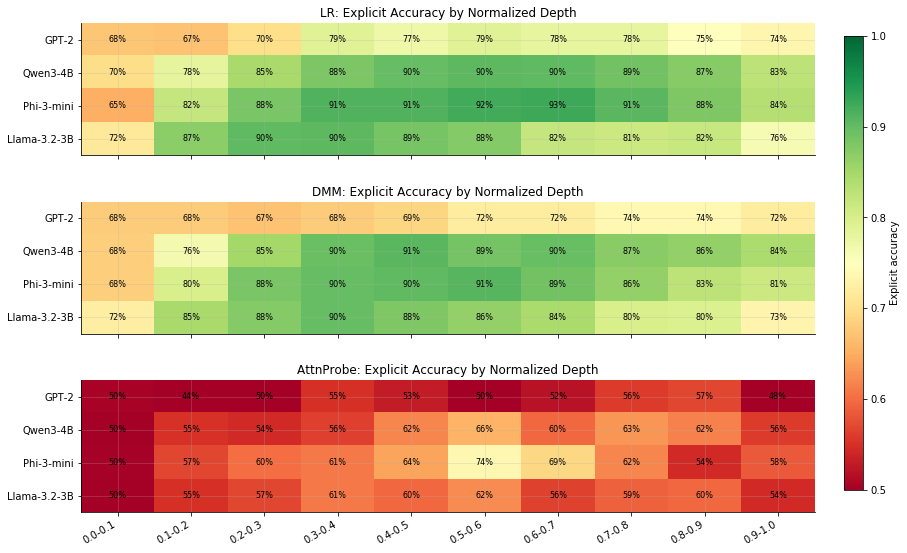

In [10]:
n_bins = 10
binned = layer_df.copy()
binned['depth_bin'] = pd.cut(
    binned['layer_frac'],
    bins=np.linspace(0, 1, n_bins + 1),
    include_lowest=True,
    labels=False,
)
binned_summary = (
    binned
    .groupby(['method_label', 'model_label', 'depth_bin'], observed=True)['explicit_acc']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(len(METHOD_ORDER), 1, figsize=(13.5, 9), sharex=True)
# Reserve a fixed strip on the right for the colorbar so it cannot cover cells/labels.
fig.subplots_adjust(right=0.88, hspace=0.35)
cbar_ax = fig.add_axes([0.91, 0.16, 0.02, 0.70])

im = None
for ax, method in zip(axes, METHOD_ORDER):
    method_label = METHOD_LABELS[method]
    pivot = binned_summary[binned_summary['method_label'] == method_label].pivot(
        index='model_label', columns='depth_bin', values='explicit_acc'
    )
    pivot = pivot.loc[[MODEL_LABELS[m] for m in MODEL_ORDER]]
    im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(f'{method_label}: Explicit Accuracy by Normalized Depth')
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if np.isfinite(val):
                ax.text(j, i, f'{val:.0%}', ha='center', va='center', fontsize=8)

axes[-1].set_xticks(range(n_bins))
axes[-1].set_xticklabels(
    [f'{i/n_bins:.1f}-{(i+1)/n_bins:.1f}' for i in range(n_bins)],
    rotation=30,
    ha='right',
)
fig.colorbar(im, cax=cbar_ax, label='Explicit accuracy')
fig.savefig(FIGURE_DIR / 'normalized_depth_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

## Cross-Validation Analysis

This mirrors the original notebook's CV error-bar plot. Here we draw one compact plot per probe method, with one panel per model.


/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ndim = x[:, None].ndim
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


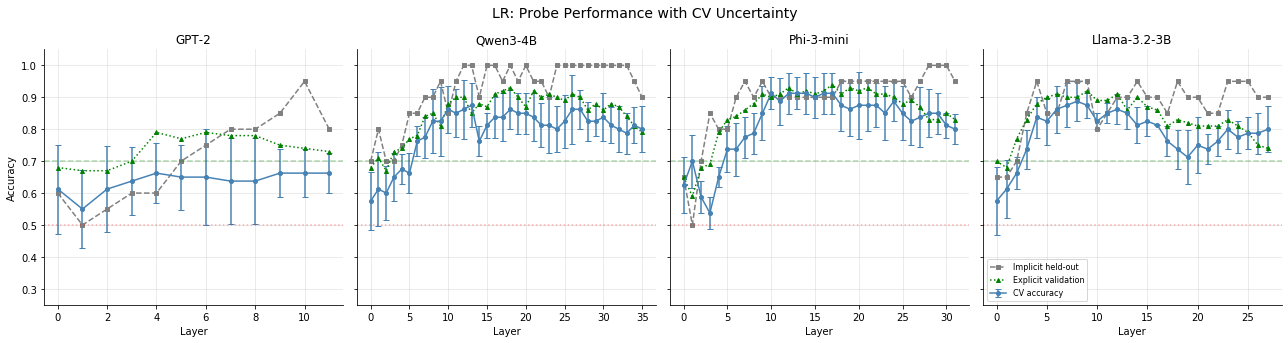

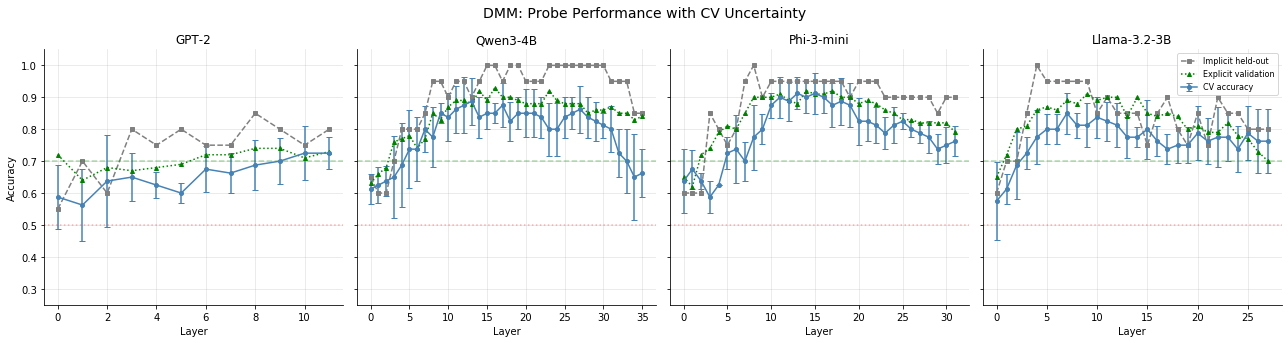

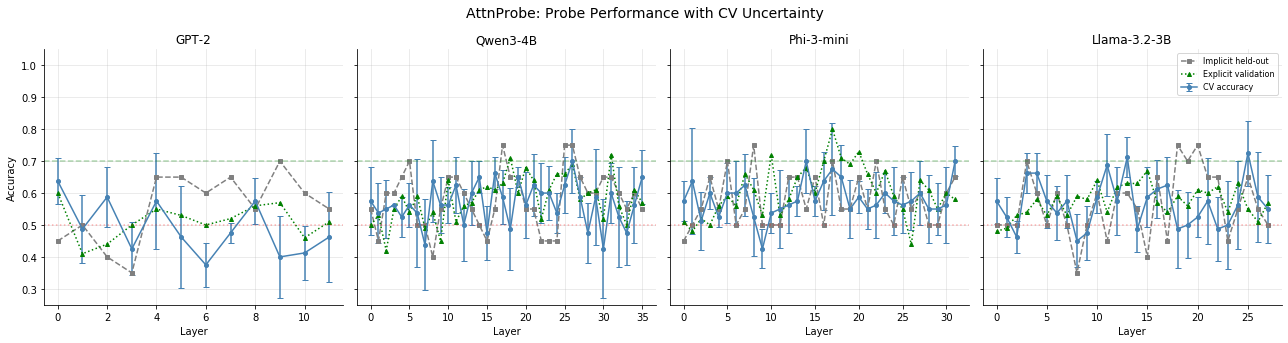

Note: Error bars show +/- 1 std from pair-aware cross-validation on the implicit training set.


In [11]:
def plot_cv_for_method(method: str):
    fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(18, 4.5), sharey=True)
    for ax, model in zip(axes, MODEL_ORDER):
        df = layer_df[(layer_df['method'] == method) & (layer_df['model'] == model)]
        x = df['layer']
        ax.errorbar(
            x, df['cv_mean'], yerr=df['cv_std'], fmt='o-', capsize=3,
            color='steelblue', label='CV accuracy', markersize=4
        )
        ax.plot(x, df['implicit_acc'], 's--', color='gray', label='Implicit held-out', markersize=4)
        ax.plot(x, df['explicit_acc'], '^:', color='green', label='Explicit validation', markersize=4)
        ax.axhline(y=0.70, color='green', linestyle='--', alpha=0.3)
        ax.axhline(y=0.50, color='red', linestyle=':', alpha=0.3)
        ax.set_title(MODEL_LABELS.get(model, model))
        ax.set_xlabel('Layer')
        ax.set_ylim(0.25, 1.05)
        if ax is axes[0]:
            ax.set_ylabel('Accuracy')
        if ax is axes[-1]:
            ax.legend(fontsize=8)
    fig.suptitle(f'{METHOD_LABELS[method]}: Probe Performance with CV Uncertainty', y=1.05, fontsize=14)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f'cv_analysis_{method}.png', dpi=150, bbox_inches='tight')
    plt.show()

for method in METHOD_ORDER:
    plot_cv_for_method(method)

print('Note: Error bars show +/- 1 std from pair-aware cross-validation on the implicit training set.')

## Probe Method Comparison

These views are not in the original single-model notebook, but they are useful now that we have multiple probe families.


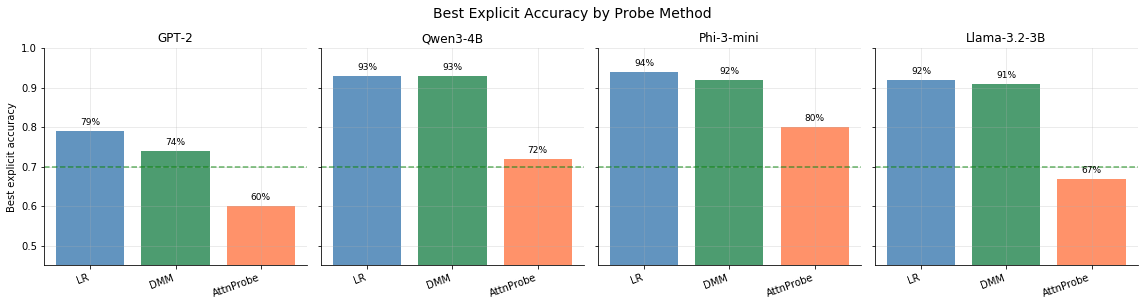

In [12]:
fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(16, 4), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    sub = summary_df[summary_df['model'] == model].sort_values('method')
    x = np.arange(len(sub))
    colors = [METHOD_COLORS[m] for m in sub['method']]
    bars = ax.bar(x, sub['best_explicit_acc'], color=colors, alpha=0.85)
    ax.axhline(0.70, color='green', linestyle='--', alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(sub['method_label'], rotation=20, ha='right')
    ax.set_title(MODEL_LABELS.get(model, model))
    ax.set_ylim(0.45, 1.0)
    for bar, val in zip(bars, sub['best_explicit_acc']):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.0%}', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('Best explicit accuracy')
fig.suptitle('Best Explicit Accuracy by Probe Method', y=1.05, fontsize=14)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'best_explicit_by_method_bars.png', dpi=150, bbox_inches='tight')
plt.show()

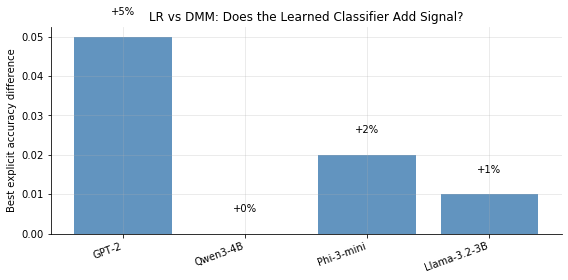

method,lr,dmm,LR - DMM
model_label,,,
GPT-2,79.0%,74.0%,+5.0%
Qwen3-4B,93.0%,93.0%,+0.0%
Phi-3-mini,94.0%,92.0%,+2.0%
Llama-3.2-3B,92.0%,91.0%,+1.0%


In [13]:
lr_dmm = summary_df[summary_df['method'].isin(['lr', 'dmm'])].pivot(
    index='model_label', columns='method', values='best_explicit_acc'
)
lr_dmm = lr_dmm.loc[[MODEL_LABELS[m] for m in MODEL_ORDER]]
lr_dmm['LR - DMM'] = lr_dmm['lr'] - lr_dmm['dmm']

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if v >= 0 else 'seagreen' for v in lr_dmm['LR - DMM']]
ax.bar(lr_dmm.index, lr_dmm['LR - DMM'], color=colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('Best explicit accuracy difference')
ax.set_title('LR vs DMM: Does the Learned Classifier Add Signal?')
ax.set_xticklabels(lr_dmm.index, rotation=20, ha='right')
for i, val in enumerate(lr_dmm['LR - DMM']):
    ax.text(i, val + (0.005 if val >= 0 else -0.01), f'{val:+.0%}', ha='center', va='bottom' if val >= 0 else 'top')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'lr_minus_dmm.png', dpi=150, bbox_inches='tight')
plt.show()

lr_dmm.style.format({'lr': '{:.1%}', 'dmm': '{:.1%}', 'LR - DMM': '{:+.1%}'})

## Saved Figures

Figures from this notebook are written separately from the previous notebooks.


In [14]:
for path in sorted(FIGURE_DIR.glob('*.png')):
    print(path.relative_to(ROOT))

results/figures/probe_validation_all_methods/all_cases_layer_grid.png
results/figures/probe_validation_all_methods/best_explicit_accuracy_heatmap.png
results/figures/probe_validation_all_methods/best_explicit_by_method_bars.png
results/figures/probe_validation_all_methods/cv_analysis_attn.png
results/figures/probe_validation_all_methods/cv_analysis_dmm.png
results/figures/probe_validation_all_methods/cv_analysis_lr.png
results/figures/probe_validation_all_methods/explicit_vs_implicit_attn_Llama-3.2-3B.png
results/figures/probe_validation_all_methods/explicit_vs_implicit_attn_Phi-3-mini-4k-instruct.png
results/figures/probe_validation_all_methods/explicit_vs_implicit_attn_Qwen3-4B.png
results/figures/probe_validation_all_methods/explicit_vs_implicit_attn_gpt2.png
results/figures/probe_validation_all_methods/explicit_vs_implicit_dmm_Llama-3.2-3B.png
results/figures/probe_validation_all_methods/explicit_vs_implicit_dmm_Phi-3-mini-4k-instruct.png
results/figures/probe_validation_all_method